In [1]:
from pathlib import Path

In [2]:
import numpy as np
import pandas as pd

In [3]:
from aeon.transformations.collection import Normalizer
from aeon.classification.distance_based import ProximityForest
from sklearn.model_selection import cross_validate, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, f1_score, accuracy_score

In [4]:
data_dir = Path('../../results')
train = pd.read_csv(data_dir / 'train_ts.csv', index_col='id')
train['action'] = train['genre'].map(lambda x: 'Action' in x)
train_X = (train[[str(i) for i in range(100)]]
           .reset_index()
           .melt(id_vars='id', var_name='time'))
train_X['time'] = train_X['time'].astype(int)
train_X = train_X.set_index(['id', 'time'])
train_X = train_X.sort_index().values.reshape((850, 1, 100))

In [5]:
train_y = train['rating_category']
train_X.shape, train_y.shape

((850, 1, 100), (850,))

In [6]:
test = pd.read_csv(data_dir / 'test_ts.csv', index_col='id')
test['action'] = test['genre'].map(lambda x: 'Action' in x)
test_X = (test[[str(i) for i in range(100)]]
          .reset_index()
          .melt(id_vars='id', var_name='time'))
test_X['time'] = test_X['time'].astype(int)
test_X = test_X.set_index(['id', 'time'])
test_X = test_X.sort_index().values.reshape((len(test), 1, 100))

test_X.shape

(284, 1, 100)

## Rating Category

This is also a distance based model that creates an ensemble of decision trees where the splits are based on the similarity between time series measured using variuos distance measures (dtw, edit distance, euclidean, etc).

In [7]:
?ProximityForest

Init signature:
ProximityForest(
    n_trees=100,
    n_splitters: int = 5,
    max_depth: Optional[int] = None,
    min_samples_split: int = 2,
    random_state: Union[int, numpy.random.mtrand.RandomState, NoneType] = None,
    n_jobs: int = 1,
    parallel_backend=None,
)
Docstring:     
Proximity Forest Classifier.

The Proximity Forest is a distance-based classifier that creates an
ensemble of decision trees, where the splits are based on the
similarity between time series measured using various parameterised
distance measures.

Parameters
----------
n_trees: int, default = 100
    The number of trees, by default an ensemble of ``100`` trees is formed.
n_splitters: int, default = 5
    The number of candidate splitters to be evaluated at each node.
max_depth: int, default = None
    The maximum depth of the tree. If ``None``, then nodes are expanded until all
    leaves are pure or until all leaves contain less than ``min_samples_split``
    samples.
min_samples_split: int, default

In [8]:
forest_params = {
    'max_depth': 5
}

In [9]:
rating_encoder = LabelEncoder()
train_y = rating_encoder.fit_transform(train['rating_category'])
rating_y_true = rating_encoder.transform(test['rating_category'])

In [10]:
%%time
rating_estimator = Pipeline([
    ('scaler', Normalizer()),
    ('clf', ProximityForest(n_jobs=-1, random_state=42, **forest_params))
])

rating_estimator.fit(train_X, train_y)

CPU times: user 29min 40s, sys: 34.6 s, total: 30min 15s
Wall time: 29min 16s


Pipeline(steps=[('scaler', Normalizer()),
                ('clf',
                 ProximityForest(max_depth=5, n_jobs=-1, random_state=42))])

In [11]:
rating_y_pred = rating_estimator.predict(test_X)

In [12]:
print(classification_report(y_true=rating_y_true, y_pred=rating_y_pred))

              precision    recall  f1-score   support

           0       0.37      0.61      0.46        95
           1       0.00      0.00      0.00         2
           2       0.37      0.40      0.38        96
           3       0.18      0.05      0.08        61
           4       0.00      0.00      0.00        30

    accuracy                           0.35       284
   macro avg       0.18      0.21      0.18       284
weighted avg       0.29      0.35      0.30       284



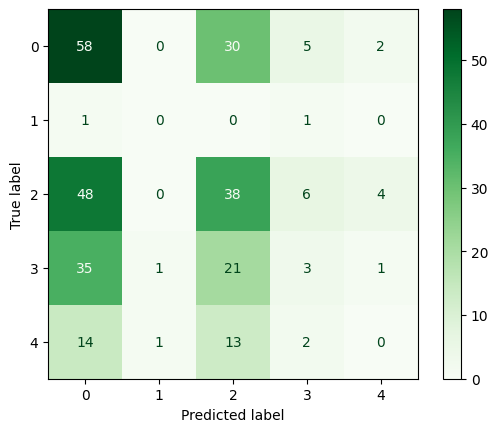

In [13]:
ConfusionMatrixDisplay.from_predictions(y_true=rating_y_true, y_pred=rating_y_pred, cmap='Greens')

In [14]:
train_predict = rating_estimator.predict(train_X)
print("Performance on the training set")
print("Accuracy:", accuracy_score(y_true=train_y, y_pred=train_predict))
print("F1 score:", f1_score(y_true=train_y, y_pred=train_predict,average='macro'))

Performance on the training set
Accuracy: 0.9552941176470588
F1 score: 0.9441900622917572


This is clearly overfitting.

## Action

In [15]:
action_encoder = LabelEncoder()
train_y = action_encoder.fit_transform(train['action'])
action_y_true = action_encoder.transform(test['action'])

In [16]:
%%time
action_estimator = Pipeline([
    ('scaler', Normalizer()),
    ('clf', ProximityForest(n_jobs=-1, random_state=42, **forest_params))
])

action_estimator.fit(train_X, train_y)

CPU times: user 14min 52s, sys: 12.7 s, total: 15min 5s
Wall time: 14min 43s


Pipeline(steps=[('scaler', Normalizer()),
                ('clf',
                 ProximityForest(max_depth=5, n_jobs=-1, random_state=42))])

In [17]:
action_y_pred = action_estimator.predict(test_X)

In [18]:
print(classification_report(y_true=action_y_true, y_pred=action_y_pred))

              precision    recall  f1-score   support

           0       0.69      1.00      0.81       195
           1       0.00      0.00      0.00        89

    accuracy                           0.69       284
   macro avg       0.34      0.50      0.41       284
weighted avg       0.47      0.69      0.56       284



/home/fab/Documents/education/data_mining/dm2_project/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/fab/Documents/education/data_mining/dm2_project/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/fab/Documents/education/data_mining/dm2_project/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter t

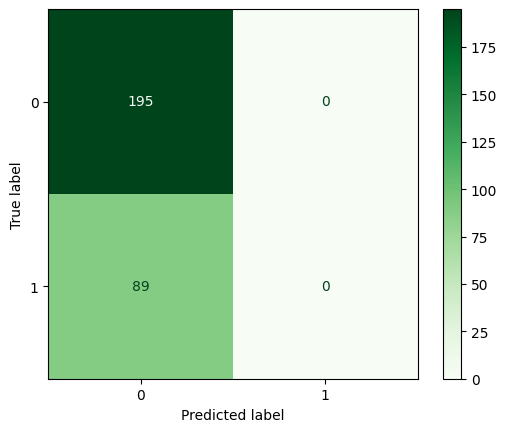

In [19]:
ConfusionMatrixDisplay.from_predictions(y_true=action_y_true, y_pred=action_y_pred, cmap='Greens')

In [20]:
train_predict = action_estimator.predict(train_X)
print("Performance on the training set")
print("Accuracy:", accuracy_score(y_true=train_y, y_pred=train_predict))
print("F1 score:", f1_score(y_true=train_y, y_pred=train_predict,average='macro'))

Performance on the training set
Accuracy: 0.6882352941176471
F1 score: 0.4251993620414673
